In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from kagglehub import KaggleDatasetAdapter
import kagglehub

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "yasserh/titanic-dataset",
    "Titanic-Dataset.csv"
)

df = df.copy()  
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Task 1: Identify Data Quality Issues

In [13]:
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Data Quality Issues:
- Missing values exist in columns such as Age, Cabin, and Embarked  
- Cabin has a large number of missing values  
- Some numerical features may contain outliers (e.g., Fare)  
- The dataset contains both categorical and numerical features  

Task 2: Handle Missing Values

In [19]:
df = df.drop(columns=['Cabin'], errors='ignore')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

- The Cabin column exists but contains a large number of missing values, so it was removed to improve data quality  
- Median was used to fill missing values in the Age column because it is robust to outliers  
- Mode was used to fill missing values in the Embarked column since it is categorical  

Task 3: Detect and Handle Outliers using IQR

In [20]:
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

mask = ~((numeric_df < (Q1 - 1.5 * IQR)) | 
         (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)

df_clean = numeric_df[mask].copy()

print("Before:", numeric_df.shape)
print("After:", df_clean.shape)

Before: (891, 7)
After: (577, 7)


Outliers were detected and removed using the IQR method, reducing the dataset size.

Task 4: Normalize Numerical Features

In [21]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
df_minmax = minmax.fit_transform(df_clean)

df_minmax = pd.DataFrame(df_minmax, columns=df_clean.columns)
df_minmax.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,0.000000,0.0,1.0,0.346939,0.5,0.0,0.118512
1,0.002247,1.0,1.0,0.428571,0.0,0.0,0.129546
2,0.003371,1.0,0.0,0.612245,0.5,0.0,0.868002
3,0.004494,0.0,1.0,0.612245,0.0,0.0,0.131590
4,0.005618,0.0,1.0,0.469388,0.0,0.0,0.138264


In [22]:
from sklearn.preprocessing import StandardScaler

zscore = StandardScaler()
df_zscore = zscore.fit_transform(df_clean)

df_zscore = pd.DataFrame(df_zscore, columns=df_clean.columns)
df_zscore.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,-1.733575,-0.654384,0.67833,-0.854761,1.800735,0.0,-0.609448
1,-1.725863,1.528156,0.67833,-0.386610,-0.448235,0.0,-0.555858
2,-1.722007,1.528156,-2.04917,0.666730,1.800735,0.0,3.030715
3,-1.718151,-0.654384,0.67833,0.666730,-0.448235,0.0,-0.545934
4,-1.714295,-0.654384,0.67833,-0.152535,-0.448235,0.0,-0.513517


- Min-Max scaling transforms values between 0 and 1  
- Z-score standardizes data based on mean and standard deviation  

Task 5: PCA

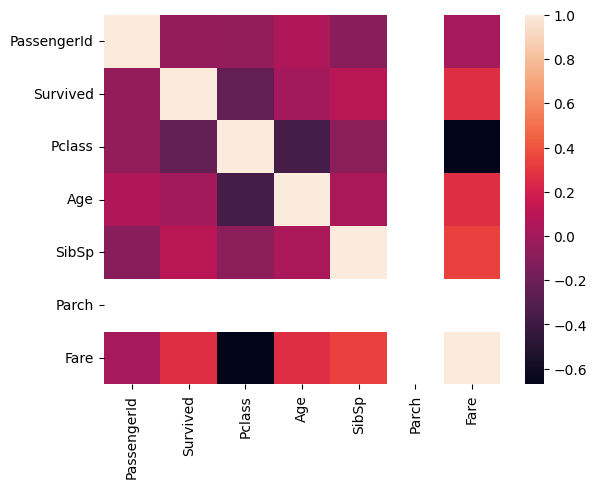

In [23]:
corr = df_clean.corr()

sns.heatmap(corr)
plt.show()

The correlation matrix shows relationships between multiple numerical features such as Age, Fare, and Parch.

Therefore, PCA is applied to reduce dimensionality.

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_zscore)

df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca.head()

,PC1,PC2
0,-0.806781,-2.322057
1,-0.549073,-1.570456
2,4.198154,-2.006881
3,-0.839887,-0.458235
4,-1.109606,-0.805146


In [25]:
df_pca.shape

(577, 2)

PCA was applied to reduce dimensionality while preserving important variance in the data.

- Data quality issues were identified and handled  
- Missing values were treated appropriately  
- Outliers were removed using IQR  
- Data was normalized using Min-Max and Z-score  
- PCA was applied based on feature correlation  